# Problem 3 — Audio entropy: ambient noise vs. music


## Method

$$
\widehat H_Q = -\sum_b \widehat p_b \log_2 \widehat p_b
$$

$$
\widehat H = \widehat H_Q + \log_2 \Delta
$$

$$
H_{\max} = \log_2 K
$$

$$
H_{\text{Gauss}} = \tfrac12 \log_2(2\pi e\widehat\sigma^2)
$$

$$
\text{gap} = H_{\text{Gauss}} - \widehat H
$$


In [146]:
# Imports and shared analysis constants.
import os
import glob
import wave
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Use only the processed WAV dataset for Problem 3.
DATA_DIR = os.path.abspath(os.path.join("..", "..", "Data", "q3"))
assert os.path.isdir(DATA_DIR), f"Processed data dir not found: {DATA_DIR}"
print("Reading WAV files from:", DATA_DIR)

# Common histogram bin width and expected audio sampling rate.
DELTA = 0.005
TARGET_SR = 16000
RNG = np.random.default_rng(4010)

# Shared plot text sizes.
AXIS_LABEL_SIZE = 16
TICK_LABEL_SIZE = 14
LEGEND_SIZE = 14

def style_axes(ax, legend=False):
    """Apply shared axis, tick, and legend text sizes."""
    ax.xaxis.label.set_size(AXIS_LABEL_SIZE)
    ax.yaxis.label.set_size(AXIS_LABEL_SIZE)
    ax.tick_params(axis="both", labelsize=TICK_LABEL_SIZE)
    if legend:
        ax.legend(fontsize=LEGEND_SIZE)


Reading WAV files from: /Users/dinhieufam/DINHHIEU/VINUNI/Spring 26/MATH4010 - Advanced Probility and Statistics/COMP4010--Advanced-Prob-Stat----Final-Project/Data/q3


In [147]:
def load_wav_mono(path):
    """Load a mono 16-bit PCM WAV file as float64 in [-1, 1)."""
    # Read WAV metadata and raw PCM bytes.
    with wave.open(path, "rb") as w:
        sr = w.getframerate()
        nch = w.getnchannels()
        sw = w.getsampwidth()
        nframes = w.getnframes()
        raw = w.readframes(nframes)

    # Convert int16 PCM to floating-point samples.
    assert sw == 2, f"{path}: expected 16-bit PCM, got sample width {sw}"
    x = np.frombuffer(raw, dtype=np.int16).astype(np.float64)

    # Downmix stereo or multi-channel audio if needed.
    if nch > 1:
        x = x.reshape(-1, nch).mean(axis=1)
    return sr, x / 32768.0


def peak_normalize(x):
    """Scale one clip to max |x| = 1, preserving silence if present."""
    peak = float(np.max(np.abs(x)))
    return x if peak == 0 else x / peak


def entropy_quantities(x, delta):
    """Return H_Q, H_diff, H_max, H_gauss, K, and sigma2 in bits."""
    # K equal-width bins on [-1, 1], where x is peak-normalized.
    K = max(2, int(np.ceil(2.0 / delta)))
    edges = np.linspace(-1.0, 1.0, K + 1)
    edges[-1] = np.nextafter(edges[-1], np.inf)

    # p_hat_b = n_b / N.
    counts, _ = np.histogram(x, bins=edges)
    p = counts.astype(np.float64) / counts.sum()
    p = p[p > 0]

    # H_Q = -sum_b p_hat_b log2(p_hat_b).
    H_Q = float(-np.sum(p * np.log2(p)))

    # H_hat = H_Q + log2(Delta).
    H_diff = float(H_Q + np.log2(delta))

    # H_max = log2(K).
    H_max = float(np.log2(K))

    # H_Gauss = 1/2 log2(2 pi e sigma_hat^2).
    sigma2 = float(np.var(x))
    H_gauss = float(0.5 * np.log2(2 * np.pi * np.e * sigma2)) if sigma2 > 0 else -np.inf
    return H_Q, H_diff, H_max, H_gauss, K, sigma2


def clip_path(cls, fname):
    """Return the path for one processed clip."""
    return os.path.join(DATA_DIR, cls, fname)


def load_clip(cls, fname, normalized=True):
    """Load a processed clip by class and filename."""
    sr, x = load_wav_mono(clip_path(cls, fname))
    assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"
    return peak_normalize(x) if normalized else x


In [148]:
# Compute one row of entropy statistics per processed clip.
rows = []
for cls in ["music", "noise"]:
    cdir = os.path.join(DATA_DIR, cls)
    assert os.path.isdir(cdir), f"Missing class folder: {cdir}"

    # Process all WAV files in the current class folder.
    for path in sorted(glob.glob(os.path.join(cdir, "*.wav"))):
        fname = os.path.basename(path)
        sr, raw = load_wav_mono(path)
        assert sr == TARGET_SR, f"{fname}: sample rate {sr} != {TARGET_SR}"

        # Peak-normalize before histogram entropy estimation.
        peak = float(np.max(np.abs(raw)))
        x = peak_normalize(raw)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)

        rows.append({
            "file": fname,
            "class": cls,
            "N": len(x),
            "duration_s": len(x) / sr,
            "peak": peak,
            "sigma2": sigma2,
            "K_bins": K,
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_max": H_max,
            "H_gauss": H_gauss,
            "gap": H_gauss - H_diff,
        })

# Keep the table in a stable class/file order.
df = pd.DataFrame(rows).sort_values(["class", "file"]).reset_index(drop=True)
assert set(df["class"]) == {"music", "noise"}
assert len(df) == 20, f"Expected 20 processed clips, found {len(df)}"
df.round(4)


,file,class,N,duration_s,peak,sigma2,K_bins,H_Q,H_diff,H_max,H_gauss,gap
0,music_01.wav,music,480000,30.0,0.1855,0.0322,400,7.2106,-0.4333,8.6439,-0.4319,0.0014
1,music_02.wav,music,480000,30.0,0.2588,0.0326,400,7.2206,-0.4233,8.6439,-0.4221,0.0012
2,music_03.wav,music,480000,30.0,0.2529,0.0213,400,6.8962,-0.7477,8.6439,-0.7285,0.0192
3,music_04.wav,music,480000,30.0,0.3104,0.0250,400,7.0247,-0.6192,8.6439,-0.6134,0.0059
4,music_05.wav,music,480000,30.0,0.2270,0.0308,400,7.1798,-0.4641,8.6439,-0.4633,0.0008
5,music_06.wav,music,480000,30.0,0.1837,0.0312,400,7.1866,-0.4573,8.6439,-0.4533,0.0040
6,music_07.wav,music,480000,30.0,0.1860,0.0239,400,6.9950,-0.6489,8.6439,-0.6462,0.0027
7,music_08.wav,music,480000,30.0,0.2108,0.0128,400,6.5373,-1.1065,8.6439,-1.0990,0.0076
8,music_09.wav,music,480000,30.0,0.1656,0.0421,400,7.4046,-0.2392,8.6439,-0.2377,0.0015
9,music_10.wav,music,480000,30.0,0.1855,0.0322,400,7.2106,-0.4333,8.6439,-0.4319,0.0014


## Class summaries


In [149]:
# Summarize entropy quantities by class.
summary = (
    df.groupby("class")[["H_Q", "H_diff", "H_max", "H_gauss", "gap", "sigma2", "duration_s"]]
      .agg(["mean", "std"])
      .round(4)
)
summary


H_Q          H_diff           H_max      H_gauss             gap  \
         mean     std    mean     std    mean  std    mean     std    mean   
class                                                                        
music  7.0866  0.2401 -0.5573  0.2401  8.6439  0.0 -0.5527  0.2369  0.0046   
noise  7.1916  0.4503 -0.4523  0.4503  8.6439  0.0 -0.4477  0.4457  0.0046   

               sigma2         duration_s       
          std    mean     std       mean  std  
class                                          
music  0.0056  0.0284  0.0080       30.0  0.0  
noise  0.0072  0.0361  0.0164       30.0  0.0

In [150]:
# Compare class means directly as music minus noise.
means = df.groupby("class")[["H_Q", "H_diff", "H_gauss", "gap", "sigma2"]].mean()
music_minus_noise = (means.loc["music"] - means.loc["noise"]).round(4)

mean_comparison = pd.DataFrame({
    "music": means.loc["music"],
    "noise": means.loc["noise"],
    "music_minus_noise": means.loc["music"] - means.loc["noise"],
}).round(4)
mean_comparison


,music,noise,music_minus_noise
H_Q,7.0866,7.1916,-0.1050
H_diff,-0.5573,-0.4523,-0.1050
H_gauss,-0.5527,-0.4477,-0.1050
gap,0.0046,0.0046,-0.0001
sigma2,0.0284,0.0361,-0.0077


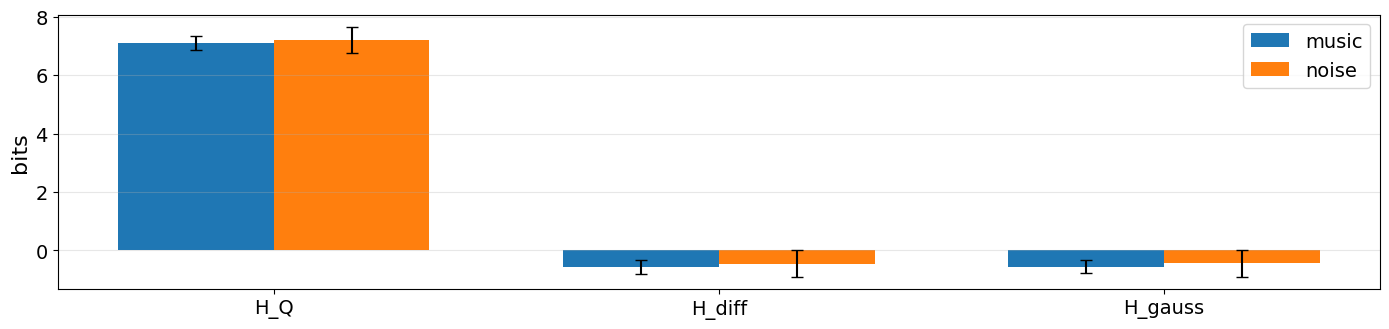

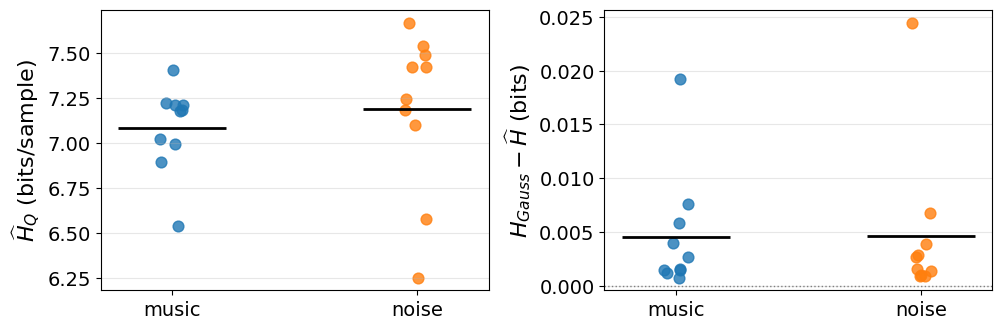

In [151]:
# Plot class-level entropy means.
fig, ax = plt.subplots(figsize=(14, 3.4))

metrics = ["H_Q", "H_diff", "H_gauss"]
x = np.arange(len(metrics))
width = 0.35
for offset, cls in [(-width / 2, "music"), (width / 2, "noise")]:
    g = df[df["class"] == cls]
    ax.bar(x + offset, [g[m].mean() for m in metrics], width,
           yerr=[g[m].std() for m in metrics], capsize=4, label=cls)
ax.set_xticks(x)
ax.set_xticklabels(metrics)
ax.set_ylabel("bits")
ax.grid(True, alpha=0.3, axis="y")
style_axes(ax, legend=True)

plt.tight_layout()
plt.show()

# Plot per-clip entropy and Gaussian gap in one row.
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
rng = np.random.default_rng(0)

ax = axes[0]
for i, cls in enumerate(["music", "noise"]):
    g = df[df["class"] == cls]
    entropy_values = g["H_Q"].to_numpy()
    jitter = rng.uniform(-0.05, 0.05, size=len(entropy_values))
    ax.scatter(np.full_like(entropy_values, i, dtype=float) + jitter,
               entropy_values, s=60, alpha=0.8, label=cls)
    ax.hlines(entropy_values.mean(), i - 0.22, i + 0.22, colors="black", linewidth=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(["music", "noise"])
ax.set_ylabel(r"$\widehat H_Q$ (bits/sample)")
ax.grid(True, alpha=0.3, axis="y")
style_axes(ax)

ax = axes[1]
for i, cls in enumerate(["music", "noise"]):
    gaps = df.loc[df["class"] == cls, "gap"].to_numpy()
    jitter = rng.uniform(-0.05, 0.05, size=len(gaps))
    ax.scatter(np.full_like(gaps, i, dtype=float) + jitter, gaps, s=60, alpha=0.8)
    ax.hlines(gaps.mean(), i - 0.22, i + 0.22, colors="black", linewidth=2)
ax.set_xticks([0, 1])
ax.set_xticklabels(["music", "noise"])
ax.set_ylabel(r"$H_{Gauss} - \widehat H$ (bits)")
ax.axhline(0, color="gray", linestyle=":", linewidth=1)
ax.grid(True, alpha=0.3, axis="y")
style_axes(ax)

plt.tight_layout()
plt.show()


## Bin-width sensitivity


In [152]:
# Recompute entropy statistics over several histogram bin widths.
deltas = np.array([2.0 ** (-k) for k in range(15, 7, -1)])
sensitivity_rows = []
for delta in deltas:
    for _, row in df.iterrows():
        x = load_clip(row["class"], row["file"], normalized=True)
        H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, delta)
        sensitivity_rows.append({
            "delta": delta,
            "file": row["file"],
            "class": row["class"],
            "H_Q": H_Q,
            "H_diff": H_diff,
            "H_gauss": H_gauss,
            "H_max": H_max,
            "gap": H_gauss - H_diff,
            "K_bins": K,
        })

# Pivot class means for compact comparison across bin widths.
sensitivity_df = pd.DataFrame(sensitivity_rows)
pivot_gap = sensitivity_df.pivot_table(index="delta", columns="class", values="gap", aggfunc="mean")
pivot_gap["music_minus_noise"] = pivot_gap["music"] - pivot_gap["noise"]
pivot_entropy = sensitivity_df.pivot_table(index="delta", columns="class", values="H_Q", aggfunc="mean")
pivot_entropy["music_minus_noise"] = pivot_entropy["music"] - pivot_entropy["noise"]
pivot_hmax = sensitivity_df.pivot_table(index="delta", columns="class", values="H_max", aggfunc="mean")
pivot_hmax["music_minus_noise"] = pivot_hmax["music"] - pivot_hmax["noise"]

bin_width_comparison = pd.concat(
    {
        "H_Q": pivot_entropy.round(4),
        "H_max": pivot_hmax.round(4),
        "gap": pivot_gap.round(4),
    },
    axis=1,
)
bin_width_comparison


H_Q                            H_max                          \
class       music    noise music_minus_noise music noise music_minus_noise   
delta                                                                        
0.000031  12.1924  12.8061           -0.6137  16.0  16.0               0.0   
0.000061  12.1924  12.7882           -0.5957  15.0  15.0               0.0   
0.000122  12.1447  12.3946           -0.2499  14.0  14.0               0.0   
0.000244  11.3765  11.5043           -0.1278  13.0  13.0               0.0   
0.000488  10.4301  10.5349           -0.1048  12.0  12.0               0.0   
0.000977   9.4383   9.5438           -0.1055  11.0  11.0               0.0   
0.001953   8.4411   8.5463           -0.1052  10.0  10.0               0.0   
0.003906   7.4425   7.5475           -0.1050   9.0   9.0               0.0   

             gap                            
class      music   noise music_minus_noise  
delta                                       
0.000031  2.2548  1.7462            0.5086  
0.000061  1.2548  0.7642            0.4907  
0.000122  0.3025  0.1577            0.1448  
0.000244  0.0708  0.0481            0.0227  
0.000488  0.0172  0.0174           -0.0002  
0.000977  0.0090  0.0086            0.0004  
0.001953  0.0061  0.0060            0.0001  
0.003906  0.0048  0.0048           -0.0000

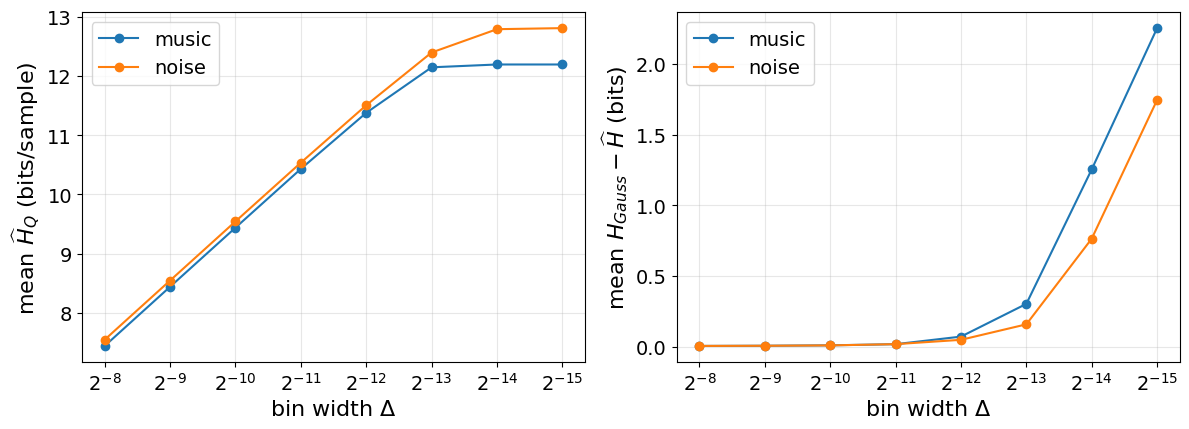

In [153]:
# Plot entropy and Gaussian-gap sensitivity to bin width.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for cls in ["music", "noise"]:
    g = sensitivity_df[sensitivity_df["class"] == cls]
    mean_by_delta = g.groupby("delta")[["H_Q", "gap"]].mean()
    axes[0].plot(mean_by_delta.index, mean_by_delta["H_Q"], marker="o", label=cls)
    axes[1].plot(mean_by_delta.index, mean_by_delta["gap"], marker="o", label=cls)

for ax in axes:
    ax.set_xscale("log", base=2)
    ax.invert_xaxis()
    ax.grid(True, alpha=0.3)
    ax.set_xlabel(r"bin width $\Delta$")
    style_axes(ax, legend=True)
axes[0].set_ylabel(r"mean $\widehat H_Q$ (bits/sample)")
axes[1].set_ylabel(r"mean $H_{Gauss} - \widehat H$ (bits)")
for ax in axes:
    style_axes(ax, legend=True)
plt.tight_layout()
plt.show()


## Bootstrap confidence intervals and effect size


In [154]:
def bootstrap_ci(values, statistic=np.mean, n_boot=10000, confidence=0.95, rng=RNG):
    """Bootstrap a confidence interval for one sample statistic."""
    values = np.asarray(values, dtype=float)
    stats = np.empty(n_boot)

    # Resample clips with replacement and evaluate the statistic.
    for b in range(n_boot):
        sample = rng.choice(values, size=len(values), replace=True)
        stats[b] = statistic(sample)

    alpha = (1 - confidence) / 2
    return float(np.quantile(stats, alpha)), float(np.quantile(stats, 1 - alpha))

# Bootstrap class-wise mean Gaussian gaps.
bootstrap_rows = []
for cls in ["noise", "music"]:
    values = df.loc[df["class"] == cls, "gap"].to_numpy()
    lo, hi = bootstrap_ci(values)
    bootstrap_rows.append({
        "quantity": f"mean gap ({cls})",
        "estimate": values.mean(),
        "ci_95_low": lo,
        "ci_95_high": hi,
    })

noise_values = df.loc[df["class"] == "noise", "gap"].to_numpy()
music_values = df.loc[df["class"] == "music", "gap"].to_numpy()

def diff_mean_stat(sampled_pairs):
    """Mean-gap difference for a concatenated noise/music bootstrap sample."""
    n = len(noise_values)
    return sampled_pairs[:n].mean() - sampled_pairs[n:].mean()

# Bootstrap each class independently for the noise-minus-music mean gap.
diff_stats = np.empty(10000)
for b in range(len(diff_stats)):
    n_sample = RNG.choice(noise_values, size=len(noise_values), replace=True)
    m_sample = RNG.choice(music_values, size=len(music_values), replace=True)
    diff_stats[b] = n_sample.mean() - m_sample.mean()

# Cohen's d for the class separation in Gaussian gap.
pooled_sd = np.sqrt(((len(noise_values) - 1) * noise_values.var(ddof=1) +
                     (len(music_values) - 1) * music_values.var(ddof=1)) /
                    (len(noise_values) + len(music_values) - 2))
cohens_d = (noise_values.mean() - music_values.mean()) / pooled_sd
bootstrap_rows.append({
    "quantity": "mean gap difference (noise - music)",
    "estimate": noise_values.mean() - music_values.mean(),
    "ci_95_low": float(np.quantile(diff_stats, 0.025)),
    "ci_95_high": float(np.quantile(diff_stats, 0.975)),
})
bootstrap_rows.append({
    "quantity": "Cohen's d for gap (noise vs music)",
    "estimate": cohens_d,
    "ci_95_low": np.nan,
    "ci_95_high": np.nan,
})

bootstrap_df = pd.DataFrame(bootstrap_rows)
bootstrap_df.round(4)


,quantity,estimate,ci_95_low,ci_95_high
0,mean gap (noise),0.0046,0.0016,0.0094
1,mean gap (music),0.0046,0.0019,0.0083
2,mean gap difference (noise - music),0.0001,-0.0053,0.0056
3,Cohen's d for gap (noise vs music),0.0106,NaN,NaN


## Recording-length sensitivity


In [155]:
# Split each processed 30-second clip into non-overlapping windows.
WINDOW_SECONDS = [1, 2, 3, 5, 6, 10, 15, 30]

length_rows = []
for _, row in df.iterrows():
    sr, raw = load_wav_mono(clip_path(row["class"], row["file"]))
    assert sr == TARGET_SR, f"{row['file']}: sample rate {sr} != {TARGET_SR}"

    # Compute entropy statistics for every full window at each duration.
    for length_s in WINDOW_SECONDS:
        window_n = int(length_s * sr)
        n_windows = len(raw) // window_n
        for window_idx in range(n_windows):
            start = window_idx * window_n
            segment = raw[start:start + window_n]
            if np.max(np.abs(segment)) == 0:
                continue

            x = peak_normalize(segment)
            H_Q, H_diff, H_max, H_gauss, K, sigma2 = entropy_quantities(x, DELTA)
            gap = H_gauss - H_diff
            if not np.isfinite(gap):
                continue

            length_rows.append({
                "class": row["class"],
                "file": row["file"],
                "length_s": length_s,
                "window_idx": window_idx,
                "H_Q": H_Q,
                "H_diff": H_diff,
                "H_gauss": H_gauss,
                "gap": gap,
                "sigma2": sigma2,
            })

length_segment_df = pd.DataFrame(length_rows)

# Average windows within each original clip before class-level summaries.
length_clip_df = (
    length_segment_df
    .groupby(["length_s", "class", "file"])[["H_Q", "H_diff", "H_gauss", "gap", "sigma2"]]
    .mean()
    .reset_index()
)

length_summary = (
    length_clip_df
    .groupby(["length_s", "class"])[["H_Q", "H_diff", "H_gauss", "gap"]]
    .agg(["mean", "std", "count"])
    .round(4)
)

# Compare music and noise means at each window length.
length_means = length_clip_df.groupby(["length_s", "class"])[["H_Q", "gap"]].mean()
length_diff = pd.DataFrame({
    "H_Q_music_minus_noise": length_means["H_Q"].unstack()["music"] - length_means["H_Q"].unstack()["noise"],
    "gap_music_minus_noise": length_means["gap"].unstack()["music"] - length_means["gap"].unstack()["noise"],
}).round(4)

length_diff


,H_Q_music_minus_noise,gap_music_minus_noise
length_s,,
1,-0.1121,-0.0023
2,-0.0998,-0.0015
3,-0.0907,-0.0013
5,-0.1053,-0.0009
6,-0.0897,-0.0007
10,-0.0858,-0.0005
15,-0.1151,-0.0001
30,-0.1050,-0.0001


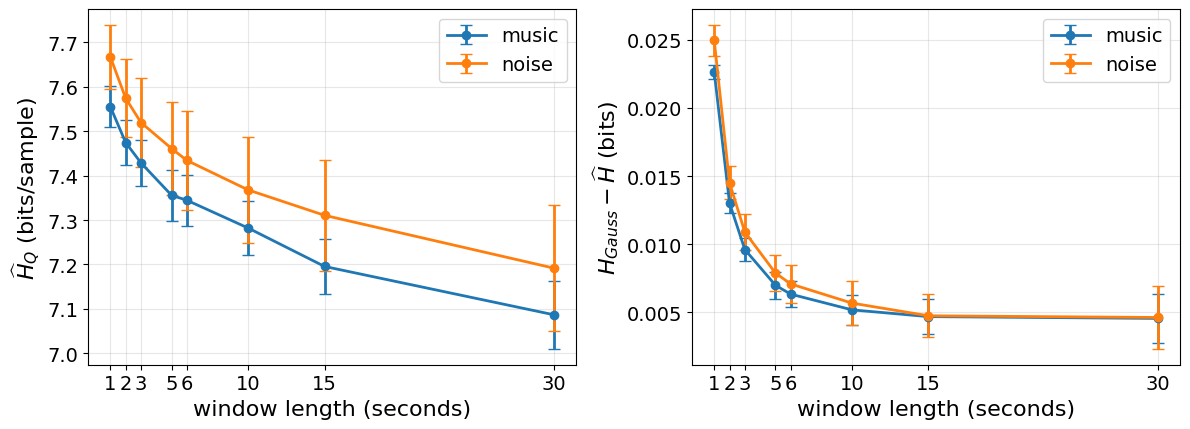

In [156]:
# Plot class means across recording-window lengths.
fig, axes = plt.subplots(1, 2, figsize=(12, 4.4))

for ax, metric, ylabel in [
    (axes[0], "H_Q", r"$\widehat H_Q$ (bits/sample)"),
    (axes[1], "gap", r"$H_{Gauss} - \widehat H$ (bits)"),
]:
    for cls in ["music", "noise"]:
        g = (
            length_clip_df[length_clip_df["class"] == cls]
            .groupby("length_s")[metric]
            .agg(["mean", "std", "count"])
        )
        sem = g["std"] / np.sqrt(g["count"])
        ax.errorbar(g.index, g["mean"], yerr=sem, marker="o", capsize=4, linewidth=2, label=cls)
    ax.set_xticks(WINDOW_SECONDS)
    ax.set_xlabel("window length (seconds)")
    ax.set_ylabel(ylabel)
    ax.grid(True, alpha=0.3)
    style_axes(ax, legend=True)

plt.tight_layout()
plt.show()
